# Exercise 12.1e solution


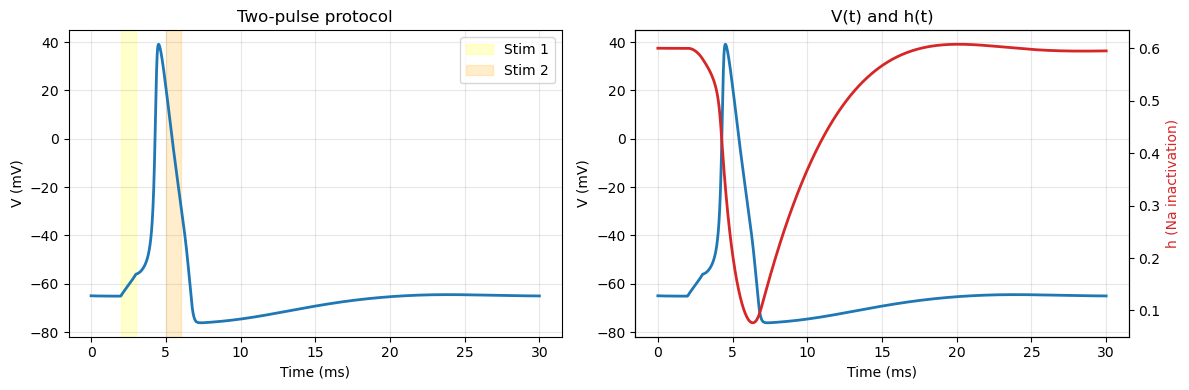

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Cm = 1.0
E_Na = 50.0
E_K = -77.0
E_L = -54.4
gNa = 120.0
gK = 36.0
gL = 0.3
I_amp = 10.0


def rhs(t, y):
    V, m, h, n = y
    alpha_m = 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
    beta_m = 4.0 * np.exp(-(V + 65) / 18)
    alpha_h = 0.07 * np.exp(-(V + 65) / 20)
    beta_h = 1.0 / (1 + np.exp(-(V + 35) / 10))
    alpha_n = 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
    beta_n = 0.125 * np.exp(-(V + 65) / 80)

    # Two stimulus pulses
    I_app = I_amp if (2 < t < 3) or (5 < t < 6) else 0.0

    I_Na = gNa * m**3 * h * (V - E_Na)
    I_K = gK * n**4 * (V - E_K)
    I_L = gL * (V - E_L)
    return [
        (-I_Na - I_K - I_L + I_app) / Cm,
        alpha_m * (1 - m) - beta_m * m,
        alpha_h * (1 - h) - beta_h * h,
        alpha_n * (1 - n) - beta_n * n,
    ]


y0 = [-65.0, 0.05, 0.6, 0.32]
sol = solve_ivp(rhs, (0, 30), y0, t_eval=np.linspace(0, 30, 3000), method="LSODA")
V, m, h, n = sol.y
t = sol.t

fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(t, V, "C0", linewidth=2)
axs[0].axvspan(2, 3, alpha=0.2, color="yellow", label="Stim 1")
axs[0].axvspan(5, 6, alpha=0.2, color="orange", label="Stim 2")
axs[0].set_xlabel("Time (ms)")
axs[0].set_ylabel("V (mV)")
axs[0].set_title("Two-pulse protocol")
axs[0].legend()
axs[0].grid(True, alpha=0.3)

axs[1].plot(t, V, "C0", linewidth=2, label="V")
ax2 = axs[1].twinx()
ax2.plot(sol.t, h, "C3", linewidth=2, label="h")
axs[1].set_xlabel("Time (ms)")
axs[1].set_ylabel("V (mV)")
ax2.set_ylabel("h (Na inactivation)", color="C3")
axs[1].set_title("V(t) and h(t)")
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

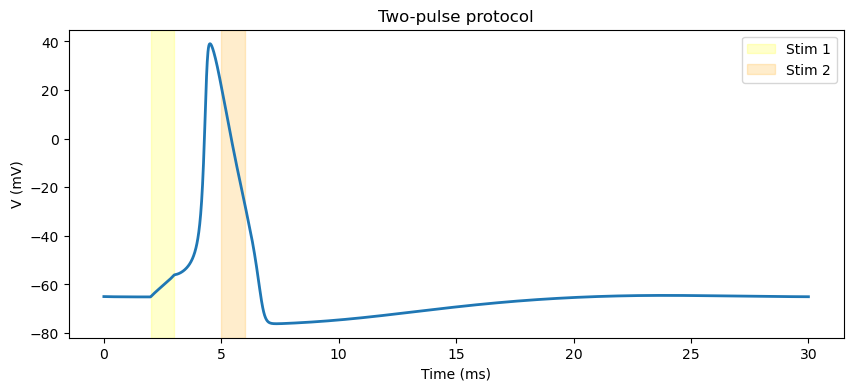

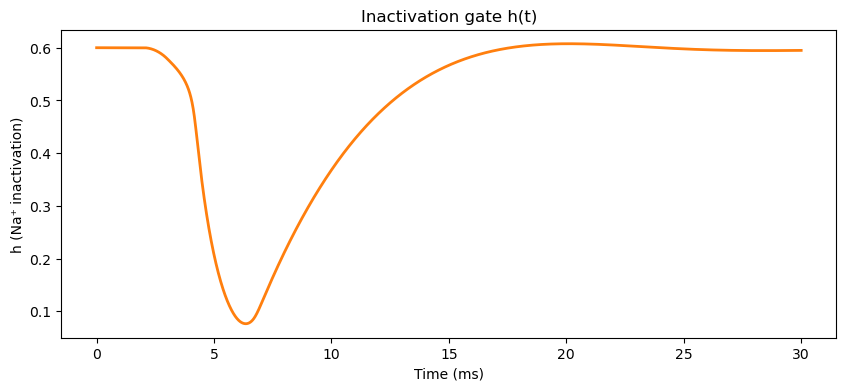

In [2]:
# Plot 1: Membrane potential with stimulus markers
plt.figure(figsize=(10, 4))
plt.plot(t, V, "C0", linewidth=2)
plt.axvspan(2, 3, alpha=0.2, color="yellow", label="Stim 1")
plt.axvspan(5, 6, alpha=0.2, color="orange", label="Stim 2")
plt.xlabel("Time (ms)")
plt.ylabel("V (mV)")
plt.title("Two-pulse protocol")
plt.legend()
plt.show()
# Plot 2: h gate during the refractory period
plt.figure(figsize=(10, 4))
plt.plot(t, h, "C1", linewidth=2)
plt.xlabel("Time (ms)")
plt.ylabel("h (Na⁺ inactivation)")
plt.title("Inactivation gate h(t)")
plt.show()

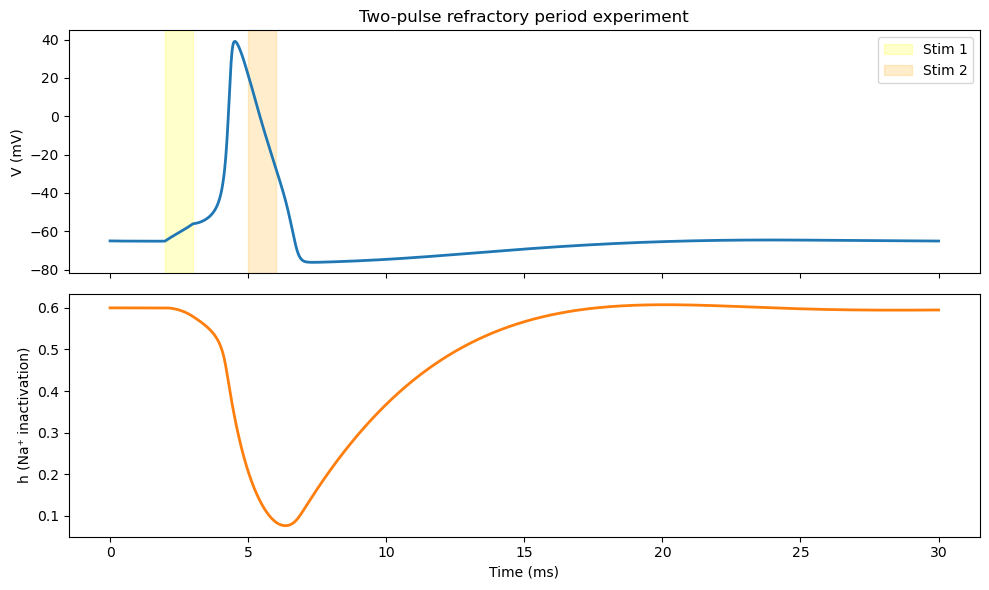

In [3]:
# Plot V(t) and h(t) to understand the refractory period
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(t, V, "C0", linewidth=2)
ax1.axvspan(2, 3, alpha=0.2, color="yellow", label="Stim 1")
ax1.axvspan(5, 6, alpha=0.2, color="orange", label="Stim 2")
ax1.set_ylabel("V (mV)")
ax1.set_title("Two-pulse refractory period experiment")
ax1.legend()

ax2.plot(t, h, "C1", linewidth=2)
ax2.set_xlabel("Time (ms)")
ax2.set_ylabel("h (Na⁺ inactivation)")

plt.tight_layout()
plt.show()


**Answers:**

1. With only 2 ms between pulse ends (second pulse at $t = 5-6$ ms), the second stimulus typically **fails** to trigger a full AP.

2. The refractory period is approximately **5–7 ms** after the first stimulus. Increasing the delay to ~10 ms between pulse starts usually allows a full second AP.

3. Looking at $h(t)$: during the first AP, the inactivation gate $h$ drops from ~0.6 to nearly 0. Even after the membrane potential has returned to rest, $h$ has not yet recovered — it takes several milliseconds for $h$ to climb back up. Without sufficient $h$, the Na⁺ channels cannot produce enough inward current to trigger a new spike, regardless of how strong the stimulus is. This is the **absolute refractory period**. As $h$ partially recovers, a larger-than-normal stimulus might trigger a smaller AP — this is the **relative refractory period**.
